In [57]:
# Imports and pip installations (if needed)
import pandas as pd

# Part 1: Load the dataset

In [58]:
# Load the given datasets
ckdCategorical = pd.read_csv('chronic_kidney_disease_categorical.csv')
ckdNumerical = pd.read_csv('chronic_kidney_disease_numerical.csv')
# Print the data
print(ckdCategorical)
print(ckdNumerical)

     unique_id   al   su       rbc        pc         pcc          ba  htn  \
0       224481  3.0  NaN       NaN       NaN  notpresent  notpresent  yes   
1       992643  0.0  0.0       NaN       NaN  notpresent  notpresent   no   
2       308740  1.0  0.0  abnormal  abnormal  notpresent  notpresent  yes   
3       450314  1.0  0.0       NaN    normal  notpresent  notpresent   no   
4       881763  0.0  0.0    normal    normal  notpresent  notpresent   no   
..         ...  ...  ...       ...       ...         ...         ...  ...   
425     769512  0.0  0.0    normal    normal  notpresent  notpresent   no   
426     872034  2.0  1.0  abnormal  abnormal  notpresent     present  yes   
427     643007  NaN  NaN       NaN    normal  notpresent  notpresent  yes   
428     840392  NaN  NaN       NaN       NaN  notpresent  notpresent  yes   
429     856244  0.0  0.0       NaN    normal  notpresent  notpresent  yes   

      dm  cad appet   pe  ane  Target  
0    yes   no  good  yes   no     c

# Part 2: Analyze the Dataset

Refer to this: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Explain what the each data is in your own words. What are the features and labels? Are the features in the given datasets : categorical, numerical or both? Give 3 examples of categorical and numerical columns each (if they exist)

Answer: The datasets consist of various people's medical data. Like their age, blood pressure, blood urea, etc. However it seems to be focused on wether the person has Chronic Kidney Disease or not. The dataset has both categorical and numerical data.

Categorical: red blood cells, pus cells, target
Numerical: age, sugar level, sodium

# Part 3: Data Preprocessing

A fundamental skill in Machine Learning is mastering the art of data cleaning and preprocessing. In this assignment, you will learn and apply essential data cleaning techniques to transform a raw dataset into a clean, ready-to-use form which you can use for regression or classification tasks. By the end of this assignment, you'll have a fully clean dataset and a solid foundation in preparing data for various machine learning models.

## Part 3.1 : Drop Duplicate rows

Let's start by checking if the given datasets have any duplicate rows (same Unique Id). Use pandas to identify and remove these duplicate rows from the given dataset

In [76]:
# For the numerical dataset, check if there are duplicate rows in the dataset. If yes, print total number of duplicate rows

duplicates_ckdNum = ckdNumerical[ckdNumerical.duplicated(subset='unique_id', keep=False)]
if duplicates_ckdNum.shape[0] > 0:
    print(duplicates_ckdNum.shape[0])
    print(duplicates_ckdNum)
    # Drop these duplicate rows
    ckdNumerical = ckdNumerical.drop_duplicates(subset='unique_id', keep='first')

# Repeat the same for categorical dataset. Print the duplicate rows and drop them
duplicates_ckdCat = ckdCategorical[ckdCategorical.duplicated(subset='unique_id', keep=False)]
print(duplicates_ckdCat.shape[0])
if duplicates_ckdCat.shape[0] > 0:
    print(duplicates_ckdCat.shape[0])
    print(duplicates_ckdCat)
    # Drop these duplicate rows
    ckdCategorical = ckdCategorical.drop_duplicates(subset='unique_id', keep='first')



0


## Part 3.2: Combine two differents datasets

A good skill to have is to know how to combine 2 different datasets.

Are all the unique ids are present in both datasets? Why do you think so? If not, what do the rows that are missing from one of the datasets look like in the combined table?


I think both tables would contain the unique ids, as both tables probably got the same data from the same sample. If one unique id is in a table and not in the other the fields the table that is missing the id would be NaN. 

Answer:

In [87]:
# Merge the two given numerical and categorical datasets based on their unique_ID.
merged_data = pd.merge(ckdCategorical, ckdNumerical, how='outer', on='unique_id')
#Print the combined dataset
print(merged_data)

     unique_id   al   su     rbc        pc         pcc          ba  htn   dm  \
0       102677  3.0  0.0  normal  abnormal  notpresent  notpresent  yes   no   
1       103570  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
2       104675  2.0  1.0  normal    normal     present  notpresent   no  yes   
3       105923  1.0  0.0     NaN    normal  notpresent  notpresent  yes  yes   
4       107297  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
..         ...  ...  ...     ...       ...         ...         ...  ...  ...   
366     995177  4.0  3.0  normal  abnormal     present     present  yes  yes   
367     996076  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
368     996412  NaN  NaN     NaN       NaN  notpresent  notpresent   no   no   
369     997629  0.0  0.0  normal    normal         NaN         NaN   no   no   
370     997876  0.0  0.0     NaN    normal  notpresent  notpresent   no   no   

     cad  ...    bp    bgr     bu    sc

## Part 3.3: Rows with Missing values

Removing missing values from a dataset is important for classification because it ensures the model is trained on complete and accurate data, leading to better performance and reliable predictions. Incomplete data can introduce bias and errors, negatively impacting the model's effectiveness.

In [88]:
# Calculate the percentage of rows that contain atleast one missing value
perct = (merged_data.isnull().any(axis=1).sum()) / (merged_data.shape[0]) * 100
# Print %
print(perct)
# Drop these rows from the dataset
dataset = merged_data.dropna()
# Print the Dataset
print(dataset)

62.8032345013477
     unique_id   al   su     rbc        pc         pcc          ba  htn   dm  \
0       102677  3.0  0.0  normal  abnormal  notpresent  notpresent  yes   no   
6       109053  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
7       114717  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
8       118596  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
10      124304  3.0  4.0  normal  abnormal  notpresent  notpresent  yes  yes   
..         ...  ...  ...     ...       ...         ...         ...  ...  ...   
361     980291  3.0  0.0  normal  abnormal  notpresent  notpresent  yes  yes   
362     991031  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
365     994377  0.0  0.0  normal    normal  notpresent  notpresent   no   no   
366     995177  4.0  3.0  normal  abnormal     present     present  yes  yes   
367     996076  0.0  0.0  normal    normal  notpresent  notpresent   no   no   

     cad  ...    bp   

## Part 3.4: Sort the dataset according to the Labels

In [89]:
# Sort the dataset according to the values in 'Target' column. Make sure reset the indices after sorting
dataset = dataset.sort_values(by='Target').reset_index(drop=True)
# Print the dataset
print(dataset)

     unique_id   al   su       rbc        pc         pcc          ba  htn  \
0       102677  3.0  0.0    normal  abnormal  notpresent  notpresent  yes   
1       310480  3.0  0.0  abnormal  abnormal     present  notpresent  yes   
2       343710  2.0  0.0  abnormal  abnormal  notpresent  notpresent  yes   
3       349892  1.0  3.0  abnormal  abnormal  notpresent  notpresent  yes   
4       353025  3.0  4.0    normal    normal  notpresent  notpresent  yes   
..         ...  ...  ...       ...       ...         ...         ...  ...   
133     418316  0.0  0.0    normal    normal  notpresent  notpresent   no   
134     411659  0.0  0.0    normal    normal  notpresent  notpresent   no   
135     390779  0.0  0.0    normal    normal  notpresent  notpresent   no   
136     614376  0.0  0.0    normal    normal  notpresent  notpresent   no   
137     996076  0.0  0.0    normal    normal  notpresent  notpresent   no   

      dm  cad  ...    bp    bgr     bu    sc    sod  pot  hemo   pcv     wb

## Part 3.5: Encoding Categorical data

In this step, we identify and process the categorical columns in the sorted dataset. We map each unique value in these columns to separate "dummy" columns.

For example, the column 'rbc' will be transformed into two columns 'rbc_normal' and 'rbc_abnormal'. If a row's value in 'rbc' is 'normal', the 'rbc_normal' column will be set to 1 and 'rbc_abnormal' will be set to 0.


**Note: Find a correct pandas function to do this **

In [90]:
# Write code here
categorical_columns = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Target']
dataset_dummies = pd.get_dummies(dataset, columns=categorical_columns)
# Print the dataset
print(dataset_dummies)
dataset = dataset_dummies

     unique_id   al   su   age    bp    bgr     bu    sc    sod  pot  ...  \
0       102677  3.0  0.0  59.0  70.0   76.0  186.0  15.0  135.0  7.6  ...   
1       310480  3.0  0.0  63.0  70.0  380.0   60.0   2.7  131.0  4.2  ...   
2       343710  2.0  0.0  61.0  80.0  173.0  148.0   3.9  135.0  5.2  ...   
3       349892  1.0  3.0  59.0  70.0  424.0   55.0   1.7  138.0  4.5  ...   
4       353025  3.0  4.0  40.0  70.0  253.0  150.0  11.9  132.0  5.6  ...   
..         ...  ...  ...   ...   ...    ...    ...   ...    ...  ...  ...   
133     418316  0.0  0.0  62.0  80.0   78.0   45.0   0.6  138.0  3.5  ...   
134     411659  0.0  0.0  32.0  60.0  102.0   17.0   0.4  147.0  4.7  ...   
135     390779  0.0  0.0  48.0  80.0  122.0   33.0   0.9  146.0  3.9  ...   
136     614376  0.0  0.0  57.0  80.0  119.0   17.0   1.2  135.0  4.7  ...   
137     996076  0.0  0.0  57.0  60.0  105.0   49.0   1.2  150.0  4.7  ...   

     cad_no  cad_yes  appet_good  appet_poor  pe_no  pe_yes  ane_no  ane_ye

In the example we went through above, another solution is to have a single column for the binary variable. In the downstream modeling would this be equivalent? What effect would this have if the categorical variable could take more than 2 values? For example, let's say we have a categorical feature that is "type of condiment" that can take 5 separate values and we are trying to predict the rating of a particular sandwich.

If the category has more than 2 values then this model would not work, as binary could only represent at maximum two different values.

## Part 3.6 : Remove Outliers from Numerical Columns

Outliers can disproportionately influence the fit of a regression model, potentially leading to a model that does not generalize well therefore it is important that we remove outliers from the numerical columns of the dataset.

For this dataset, we define an outlier to be 3 times the standard deviation from the mean. Drop these outliers from the dataset

In [91]:
# Remove outliers
numerical_columns = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
for col in numerical_columns:
    mean = dataset[col].mean()
    std_dev = dataset[col].std()
    cutoff = std_dev * 3
    dataset = dataset[(dataset[col] >= mean - cutoff) & (dataset[col] <= mean + cutoff)]
# Print the dataset
print(dataset)

     unique_id   al   su   age     bp    bgr     bu   sc    sod  pot  ...  \
2       343710  2.0  0.0  61.0   80.0  173.0  148.0  3.9  135.0  5.2  ...   
6       615697  4.0  0.0   6.0   60.0   94.0   67.0  1.0  135.0  4.9  ...   
7       397388  2.0  2.0  63.0  100.0  280.0   35.0  3.2  143.0  3.5  ...   
11      438182  2.0  0.0  73.0   80.0  253.0  142.0  4.6  138.0  5.8  ...   
13      474407  4.0  0.0  21.0   90.0  107.0   40.0  1.7  125.0  3.5  ...   
..         ...  ...  ...   ...    ...    ...    ...  ...    ...  ...  ...   
133     418316  0.0  0.0  62.0   80.0   78.0   45.0  0.6  138.0  3.5  ...   
134     411659  0.0  0.0  32.0   60.0  102.0   17.0  0.4  147.0  4.7  ...   
135     390779  0.0  0.0  48.0   80.0  122.0   33.0  0.9  146.0  3.9  ...   
136     614376  0.0  0.0  57.0   80.0  119.0   17.0  1.2  135.0  4.7  ...   
137     996076  0.0  0.0  57.0   60.0  105.0   49.0  1.2  150.0  4.7  ...   

     cad_no  cad_yes  appet_good  appet_poor  pe_no  pe_yes  ane_no  ane_ye

## Part 3.7 : Normalize the Numerical Columns

Normalizing numerical attributes ensures that all features contribute equally to the model by scaling them to a consistent range, which improves model performance and convergence. It prevents features with larger scales from disproportionately influencing the model's learning process.

In [92]:
# Normalize the all Numerical Attributes in the dataset.
# Initialize the MinMaxScaler

for col in numerical_columns:
    minVal = dataset[col].min()
    range = dataset[col].max() - dataset[col].min()
    dataset[col] = (dataset[col] - minVal) / range
# Print the dataset
print(dataset)

     unique_id   al   su       age    bp       bgr        bu        sc  \
2       343710  2.0  0.0  0.743243  0.50  0.442060  0.901961  0.432099   
6       615697  4.0  0.0  0.000000  0.00  0.103004  0.372549  0.074074   
7       397388  2.0  2.0  0.770270  1.00  0.901288  0.163399  0.345679   
11      438182  2.0  0.0  0.905405  0.50  0.785408  0.862745  0.518519   
13      474407  4.0  0.0  0.202703  0.75  0.158798  0.196078  0.160494   
..         ...  ...  ...       ...   ...       ...       ...       ...   
133     418316  0.0  0.0  0.756757  0.50  0.034335  0.228758  0.024691   
134     411659  0.0  0.0  0.351351  0.00  0.137339  0.045752  0.000000   
135     390779  0.0  0.0  0.567568  0.50  0.223176  0.150327  0.061728   
136     614376  0.0  0.0  0.689189  0.50  0.210300  0.045752  0.098765   
137     996076  0.0  0.0  0.689189  0.00  0.150215  0.254902  0.098765   

          sod       pot  ...  cad_no  cad_yes  appet_good  appet_poor  pe_no  \
2    0.500000  0.793103  ...   

## Part 3.8: Remove Unnecessary columns

Are there any columns in this dataset which are not appropriate for modeling and predictions? Which column(s)? Justify their exclusion and remove them

There are many columns I can get rid off: ['rbc_abnormal', 'pc_abnormal', 'pcc_notpresent', 'ba_notpresent', 'htn_no', 'dm_no', 'cad_no', 'appet_poor', 'pe_no', 'ane_no', 'Target_notckd']. All of these columns record the exact opposite data of thier adjacent column, so they store the exact same data, so they are redundant.

Answer:

In [93]:
#Remove that column
col_remove =  ['rbc_abnormal', 'pc_abnormal', 'pcc_notpresent', 'ba_notpresent', 'htn_no', 'dm_no', 'cad_no', 'appet_poor', 'pe_no', 'ane_no', 'Target_notckd']
dataset = dataset.drop(columns=col_remove)
# Print the dataset
print(dataset)

     unique_id   al   su       age    bp       bgr        bu        sc  \
2       343710  2.0  0.0  0.743243  0.50  0.442060  0.901961  0.432099   
6       615697  4.0  0.0  0.000000  0.00  0.103004  0.372549  0.074074   
7       397388  2.0  2.0  0.770270  1.00  0.901288  0.163399  0.345679   
11      438182  2.0  0.0  0.905405  0.50  0.785408  0.862745  0.518519   
13      474407  4.0  0.0  0.202703  0.75  0.158798  0.196078  0.160494   
..         ...  ...  ...       ...   ...       ...       ...       ...   
133     418316  0.0  0.0  0.756757  0.50  0.034335  0.228758  0.024691   
134     411659  0.0  0.0  0.351351  0.00  0.137339  0.045752  0.000000   
135     390779  0.0  0.0  0.567568  0.50  0.223176  0.150327  0.061728   
136     614376  0.0  0.0  0.689189  0.50  0.210300  0.045752  0.098765   
137     996076  0.0  0.0  0.689189  0.00  0.150215  0.254902  0.098765   

          sod       pot  ...  pc_normal  pcc_present  ba_present  htn_yes  \
2    0.500000  0.793103  ...      

## Part 3.9: Export the Cleaned Data

Now that you've completed these cleaning steps you should have a pandas dataframe which is much cleaner and ready for modeling. Our final step is to save our work. Export the DataFrame to a two new formats: csv and json.

In [94]:
# Export the dataframe to a new csv file
dataset.to_csv('clean_data.csv', index=False)
# Export the dataframe to a new json file
dataset.to_json('cleaned_data.json', orient='records', lines=True)

# Part 4: Data conversions with Large Language Models

One powerful use case of ChatGPT (and other generative language models) is cleaning and transforming data. In some cases, these models can directly manipulate loosely structured data that you provide to them into a standard format. In the other cases, you can often prompt the model to create a conversion or extraction script for you in python or Pandas and then run it on your own. 

In this part of the assignment you will prompt 383GPT to explore these capabilities.

## Part 4.1 GPT Data Manipulation

Take the cleaned dataset that you created in part three and output the top 15 rows of that dataset. Then copy the terminal output, open 383gpt and ask it to convert that output to a markdown table. Paste that markdown table in the cell bellow

In [95]:
cleanedData = pd.read_csv('clean_data.csv')
print(cleanedData.head(15))

    unique_id   al   su       age    bp       bgr        bu        sc  \
0      343710  2.0  0.0  0.743243  0.50  0.442060  0.901961  0.432099   
1      615697  4.0  0.0  0.000000  0.00  0.103004  0.372549  0.074074   
2      397388  2.0  2.0  0.770270  1.00  0.901288  0.163399  0.345679   
3      438182  2.0  0.0  0.905405  0.50  0.785408  0.862745  0.518519   
4      474407  4.0  0.0  0.202703  0.75  0.158798  0.196078  0.160494   
5      475200  4.0  2.0  0.783784  1.00  0.399142  0.287582  0.839506   
6      481293  3.0  1.0  0.729730  0.00  0.935622  0.169935  0.160494   
7      514721  2.0  0.0  0.675676  0.75  0.253219  0.633987  0.777778   
8      532520  2.0  0.0  0.729730  0.75  0.150215  0.281046  0.234568   
9      995177  4.0  3.0  0.851351  0.25  0.618026  0.562092  0.728395   
10     546225  1.0  0.0  0.540541  0.00  0.399142  0.535948  0.358025   
11     621332  1.0  0.0  0.716216  0.50  1.000000  0.163399  0.111111   
12     828592  3.0  0.0  0.878378  0.25  0.639485  

### Paste the markdown table here

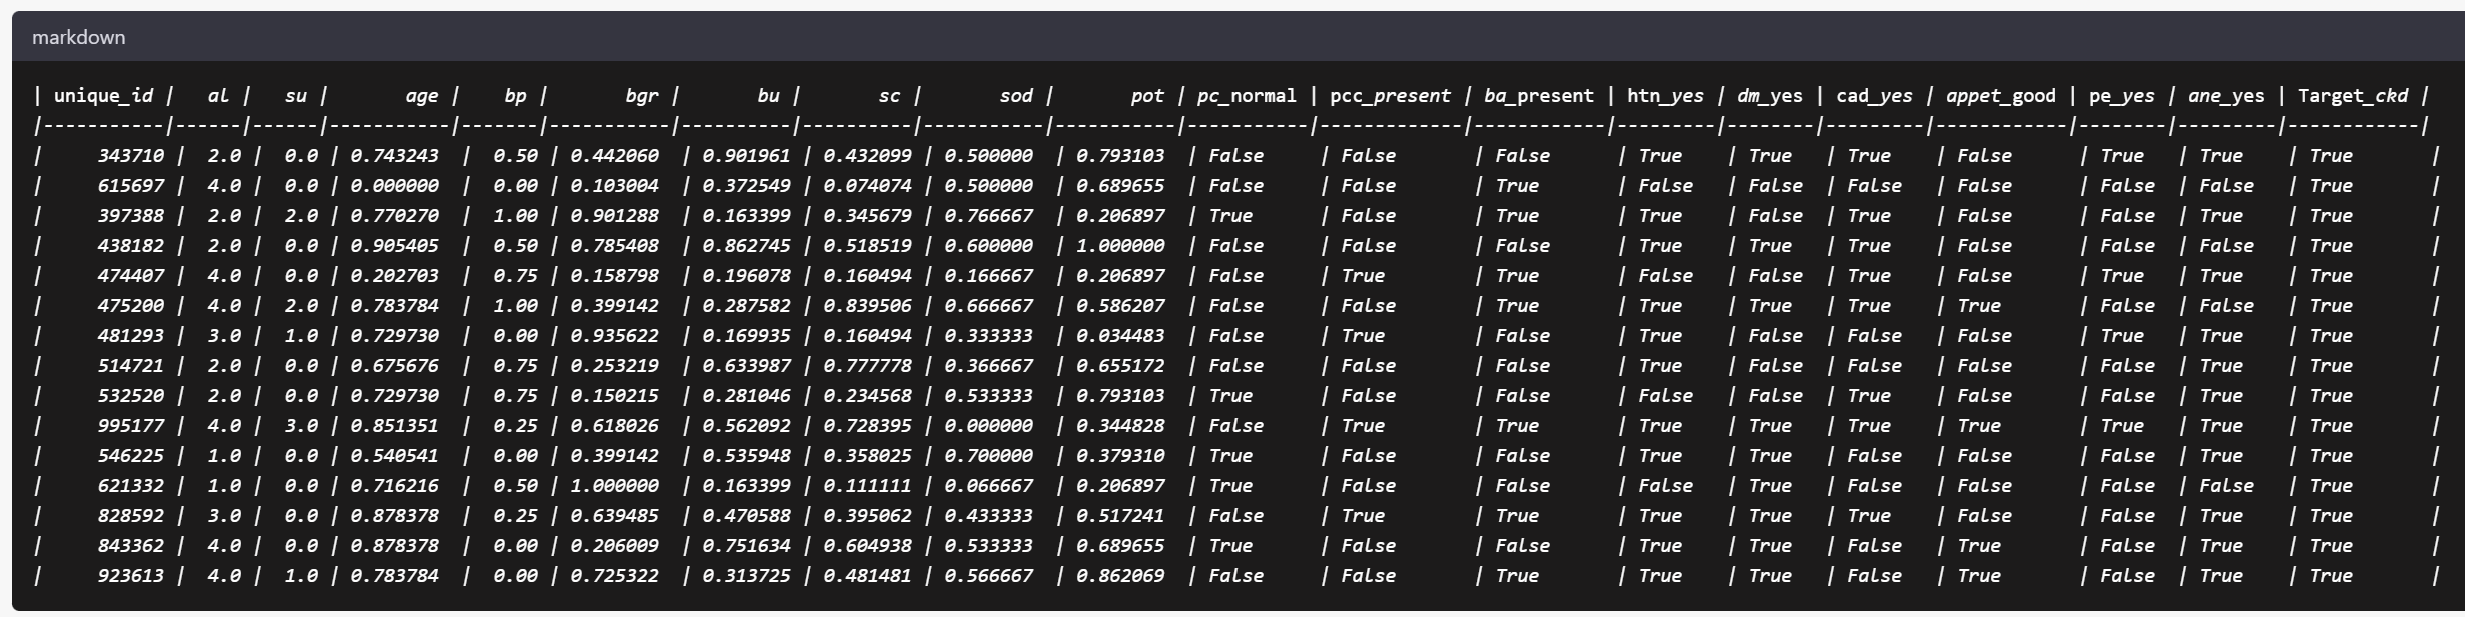

** Caution: ** while language models can perform data conversions they also can * hallucinate * during this process, particularly for bigger datasets. Reflect on this below, how could you mitigate data conversion hallucinations from LLM conversions?

I would ask the LLM to go step by step and explain it's logic. I would also keep asking the LLM multiple times to see if the output varies by a large amount.

## Part 4.2 GPT Pandas Prompting

In this section, you will prompt 383GPT to write pandas code manipulations for you.

After working with this data for awhile, we realized we're starting to forget the meanings of the abbreviated column names. Let's ask 383GPT to fix this for us. First, navigate to the [UCI dataset overview](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease) and copy the abbrevation to name mapping. Then, go to 383GPT and instruct the LLM to provide you with a pandas script to apply this renaming to all the columns of your dataset. Paste that code below and make any adjustments necessary to run it in your notebook.

In [96]:
# Code to rename all the columns in the dataset
column_mapping = {
    'age': 'age',
    'bp': 'blood pressure',
    'sg': 'specific gravity',
    'al': 'albumin',
    'su': 'sugar',
    'rbc': 'red blood cells',
    'pc': 'pus cell',
    'pcc': 'pus cell clumps',
    'ba': 'bacteria',
    'bgr': 'blood glucose random',
    'bu': 'blood urea',
    'sc': 'serum creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed cell volume',
    'wc': 'white blood cell count',
    'rc': 'red blood cell count',
    'htn': 'hypertension',
    'dm': 'diabetes mellitus',
    'cad': 'coronary artery disease',
    'appet': 'appetite',
    'pe': 'pedal edema',
    'ane': 'anemia',
    'class': 'class'
}

# Rename the columns using the mapping
cleanedData.rename(columns=column_mapping, inplace=True)

## Part 4.3 Augmenting our skills with prompting

In addition, we can also use 383GPT to convert our data manipulation operations between different data manipulation languages and libraries. For example let's prompt 383GPT to convert the following SQL query to a pandas query.

**SQL Query**
```sql
SELECT Target, COUNT(*) AS count
FROM your_table_name
GROUP BY Target;
```

Prompt 383GPT to convert this to a pandas query. Run this query below, then describe what it does. (If you're not familiar with SQL that is okay you need to only comment on the final resulting output.)

In [98]:
# Converted SQL to Pandas code

# Load your DataFrame (assuming it's already loaded)
# df = pd.read_csv('your_file.csv')  # Replace this line with your DataFrame loading code

# Group by 'Target' and count occurrences
result = cleanedData.groupby('Target_ckd').size().reset_index(name='count')

# Display the result
print(result)

   Target_ckd  count
0       False     98
1        True     22


*Describe what the above code does here*
The gives the total number of samples with and without ckd